# 02 - Baseline Experiments

This notebook trains and evaluates two baseline methods:
1. Logistic Regression on flattened pixel features
2. Shallow CNN trained from scratch

Both baselines serve as reference points for the more advanced models.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from src.data import get_flat_features, get_dataloaders
from src.models import get_model, get_optimizer, FocalLoss
from src.train import run_experiment
from src.evaluate import (
    compute_metrics, evaluate_model, find_optimal_threshold,
    plot_confusion_matrix, plot_roc_curve, plot_training_history,
)
from src.utils import set_seed, get_device, load_config, save_results

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

config = load_config("../configs/default.yaml")
device = get_device()
DATA_ROOT = "../data/chest_xray"
SEED = config["reproducibility"]["seed"]

print(f"Device: {device}")

Device: cuda


## Baseline 1: Logistic Regression

We flatten 64x64 grayscale images into 4096-dimensional vectors
and train an L2-regularized logistic regression classifier.

In [2]:
set_seed(SEED)

print("Loading flattened features...")
flat_data = get_flat_features(DATA_ROOT, image_size=64, seed=SEED)

print(f"Train: {flat_data['X_train'].shape}")
print(f"Val:   {flat_data['X_val'].shape}")
print(f"Test:  {flat_data['X_test'].shape}")

Loading flattened features...
Train: (4447, 4096)
Val:   (785, 4096)
Test:  (624, 4096)


In [3]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    class_weight="balanced",
    random_state=SEED,
)
lr_model.fit(flat_data["X_train"], flat_data["y_train"])

val_proba_lr = lr_model.predict_proba(flat_data["X_val"])[:, 1]
test_proba_lr = lr_model.predict_proba(flat_data["X_test"])[:, 1]

val_metrics_lr = compute_metrics(flat_data["y_val"], val_proba_lr)
test_metrics_lr = compute_metrics(flat_data["y_test"], test_proba_lr)

print(f"\nValidation - AUROC: {val_metrics_lr['auroc']:.4f}, F1: {val_metrics_lr['f1_macro']:.4f}")
print(f"Test       - AUROC: {test_metrics_lr['auroc']:.4f}, F1: {test_metrics_lr['f1_macro']:.4f}")
print(f"             Sensitivity: {test_metrics_lr['sensitivity']:.4f}, "
      f"Specificity: {test_metrics_lr['specificity']:.4f}")

Training Logistic Regression...

Validation - AUROC: 0.9901, F1: 0.9415
Test       - AUROC: 0.8971, F1: 0.6871
             Sensitivity: 0.9872, Specificity: 0.3761


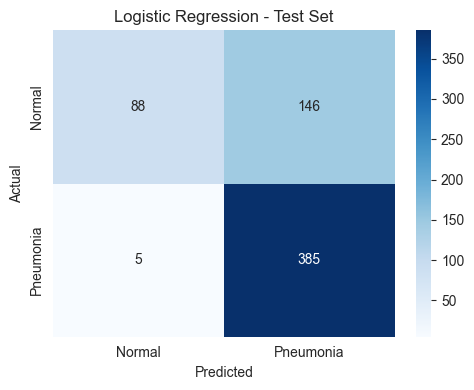

In [4]:
lr_results = {
    "metrics": test_metrics_lr,
    "y_true": flat_data["y_test"],
    "y_proba": test_proba_lr,
}

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion_matrix(
    flat_data["y_test"], test_proba_lr,
    title="Logistic Regression - Test Set", ax=ax,
)
plt.tight_layout()
plt.savefig("../results/baseline_lr_confusion.png", bbox_inches="tight")
plt.show()

## Baseline 2: Shallow CNN

A 3-layer CNN trained from scratch with weighted binary cross-entropy.

In [5]:
set_seed(SEED)

dataloaders = get_dataloaders(
    DATA_ROOT,
    augmentation="basic",
    image_size=config["data"]["image_size"],
    batch_size=config["training"]["batch_size"],
    val_split=config["data"]["val_split"],
    num_workers=0,
    seed=SEED,
)

print(f"Train batches: {len(dataloaders['train'])}")
print(f"Val batches:   {len(dataloaders['val'])}")
print(f"Test batches:  {len(dataloaders['test'])}")

Train batches: 138
Val batches:   25
Test batches:  20


In [6]:
set_seed(SEED)

cnn_model = get_model("shallow_cnn", dropout=config["model"]["dropout"])

cnn_config = config.copy()
cnn_config["model"]["use_focal_loss"] = False

cnn_results = run_experiment(
    model_name="shallow_cnn",
    model=cnn_model,
    dataloaders=dataloaders,
    device=device,
    config=cnn_config,
    experiment_name="baseline_shallow_cnn",
)

Epoch   1/15 | Train Loss: 0.2021 | Val Loss: 0.1573 | Val AUROC: 0.9599 | F1: 0.8490 *
Epoch   2/15 | Train Loss: 0.1512 | Val Loss: 0.1844 | Val AUROC: 0.9498 | F1: 0.8625 
Epoch   3/15 | Train Loss: 0.1459 | Val Loss: 0.1191 | Val AUROC: 0.9678 | F1: 0.8896 *
Epoch   4/15 | Train Loss: 0.1423 | Val Loss: 0.5698 | Val AUROC: 0.9259 | F1: 0.4555 
Epoch   5/15 | Train Loss: 0.1295 | Val Loss: 0.1334 | Val AUROC: 0.9763 | F1: 0.8329 *
Epoch   6/15 | Train Loss: 0.1262 | Val Loss: 0.1366 | Val AUROC: 0.9748 | F1: 0.8367 
Epoch   7/15 | Train Loss: 0.1197 | Val Loss: 0.2579 | Val AUROC: 0.9768 | F1: 0.7569 *
Epoch   8/15 | Train Loss: 0.1185 | Val Loss: 0.2107 | Val AUROC: 0.9702 | F1: 0.7341 
Epoch   9/15 | Train Loss: 0.1122 | Val Loss: 0.0984 | Val AUROC: 0.9832 | F1: 0.9233 *
Epoch  10/15 | Train Loss: 0.1100 | Val Loss: 0.1073 | Val AUROC: 0.9814 | F1: 0.8802 
Epoch  11/15 | Train Loss: 0.1053 | Val Loss: 0.0841 | Val AUROC: 0.9866 | F1: 0.9049 *
Epoch  12/15 | Train Loss: 0.1043 | V

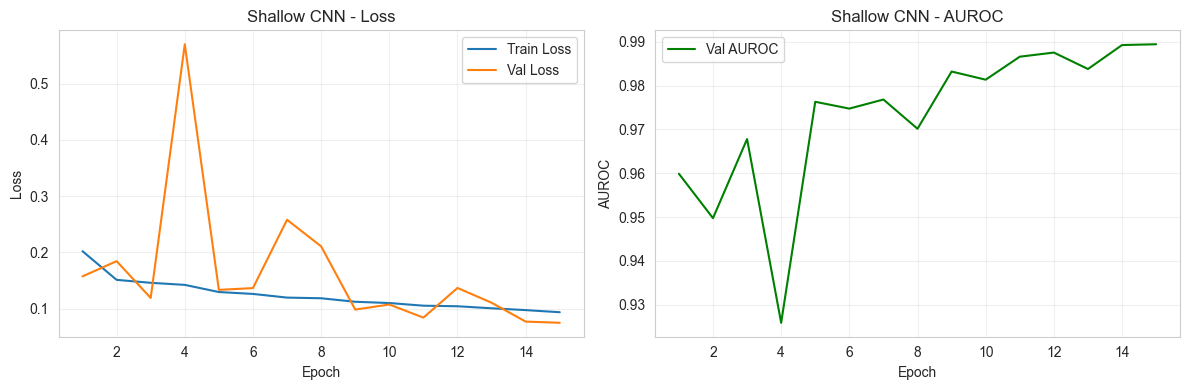

In [7]:
fig = plot_training_history(cnn_results["history"], title="Shallow CNN")
plt.savefig("../results/baseline_cnn_training.png", bbox_inches="tight")
plt.show()

Shallow CNN - Test Results:
  AUROC:       0.9139
  F1 (macro):  0.7886
  Sensitivity: 0.9487
  Specificity: 0.5983
  NPV:         0.8750


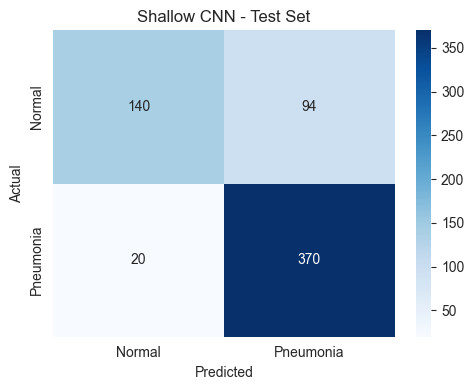

In [8]:
cnn_test = evaluate_model(cnn_model, dataloaders["test"], device)

print("Shallow CNN - Test Results:")
print(f"  AUROC:       {cnn_test['metrics']['auroc']:.4f}")
print(f"  F1 (macro):  {cnn_test['metrics']['f1_macro']:.4f}")
print(f"  Sensitivity: {cnn_test['metrics']['sensitivity']:.4f}")
print(f"  Specificity: {cnn_test['metrics']['specificity']:.4f}")
print(f"  NPV:         {cnn_test['metrics']['npv']:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion_matrix(
    cnn_test["y_true"], cnn_test["y_proba"],
    title="Shallow CNN - Test Set", ax=ax,
)
plt.tight_layout()
plt.savefig("../results/baseline_cnn_confusion.png", bbox_inches="tight")
plt.show()

## Summary of Baseline Results

In [9]:
import pandas as pd

baseline_results = {
    "Logistic Regression": lr_results,
    "Shallow CNN": cnn_test,
}

summary_rows = []
for name, res in baseline_results.items():
    m = res["metrics"]
    summary_rows.append({
        "Model": name,
        "AUROC": f"{m['auroc']:.4f}",
        "F1 (macro)": f"{m['f1_macro']:.4f}",
        "Sensitivity": f"{m['sensitivity']:.4f}",
        "Specificity": f"{m['specificity']:.4f}",
        "NPV": f"{m['npv']:.4f}",
    })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

              Model  AUROC F1 (macro) Sensitivity Specificity    NPV
Logistic Regression 0.8971     0.6871      0.9872      0.3761 0.9462
        Shallow CNN 0.9139     0.7886      0.9487      0.5983 0.8750


In [10]:
save_results(
    {"logistic_regression": test_metrics_lr, "shallow_cnn": cnn_test["metrics"]},
    "baseline_results",
    output_dir="../results",
)
print("Baseline results saved.")

Baseline results saved.


In [11]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

## 6. Random / Trivial Baselines (Sanity Checks)

These are non-learning baselines that any reasonable model must beat. They use the
same train/val/test split as the Logistic Regression baseline above (`flat_data`
from the cell where we called `get_flat_features`).

- **Majority class baseline**: always predicts PNEUMONIA (the dominant class).
- **Stratified random baseline**: predicts proportional to the training class distribution.
- **Uniform random baseline**: predicts each class with 50% probability.

If any deep learning model fails to beat the majority baseline on F1-macro or NPV,
something is wrong with training. The point of these baselines is to expose that.

In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score

# Pull the labels we already have from get_flat_features (these MUST exist from
# the Logistic Regression cells above; this notebook depends on them).
y_train = flat_data["y_train"]
y_test  = flat_data["y_test"]

print(f"Train labels: {np.bincount(y_train).tolist()} (Normal, Pneumonia)")
print(f"Test  labels: {np.bincount(y_test).tolist()}  (Normal, Pneumonia)")

# Dummy classifiers don't look at features, so any constant-shaped X will do.
X_train_dummy = np.zeros((len(y_train), 1))
X_test_dummy  = np.zeros((len(y_test),  1))

dummy_strategies = {
    "majority_baseline":    DummyClassifier(strategy="most_frequent"),
    "stratified_baseline":  DummyClassifier(strategy="stratified", random_state=SEED),
    "uniform_baseline":     DummyClassifier(strategy="uniform",    random_state=SEED),
}

random_baseline_results = {}
for name, dummy in dummy_strategies.items():
    dummy.fit(X_train_dummy, y_train)
    # predict_proba gives probability for class 1 (PNEUMONIA) in column 1
    proba = dummy.predict_proba(X_test_dummy)[:, 1]
    metrics = compute_metrics(y_test, proba, threshold=0.5)
    random_baseline_results[name] = metrics
    print(f"\n--- {name} ---")
    print(f"  AUROC:       {metrics['auroc']:.4f}")
    print(f"  F1 (macro):  {metrics['f1_macro']:.4f}")
    print(f"  Sensitivity: {metrics['sensitivity']:.4f}")
    print(f"  Specificity: {metrics['specificity']:.4f}")
    print(f"  NPV:         {metrics['npv']:.4f}")
    print(f"  Confusion:   TP={metrics['tp']} FP={metrics['fp']} TN={metrics['tn']} FN={metrics['fn']}")

Train labels: [1147, 3300] (Normal, Pneumonia)
Test  labels: [234, 390]  (Normal, Pneumonia)

--- majority_baseline ---
  AUROC:       0.5000
  F1 (macro):  0.3846
  Sensitivity: 1.0000
  Specificity: 0.0000
  NPV:         0.0000
  Confusion:   TP=390 FP=234 TN=0 FN=0

--- stratified_baseline ---
  AUROC:       0.4795
  F1 (macro):  0.4716
  Sensitivity: 0.7154
  Specificity: 0.2436
  NPV:         0.3393
  Confusion:   TP=279 FP=177 TN=57 FN=111

--- uniform_baseline ---
  AUROC:       0.5000
  F1 (macro):  0.3846
  Sensitivity: 1.0000
  Specificity: 0.0000
  NPV:         0.0000
  Confusion:   TP=390 FP=234 TN=0 FN=0


In [13]:
# Combine all baseline numbers (LR, Shallow CNN, three random baselines) into one
# JSON so the final presentation can pull them from a single source.
combined_baseline_results = {
    "logistic_regression": test_metrics_lr,
    "shallow_cnn":         cnn_test["metrics"],
    **random_baseline_results,
}

save_results(combined_baseline_results, "baseline_results", output_dir="../results")
print("Saved combined baseline results (logistic regression + shallow CNN + 3 random baselines).")

Saved combined baseline results (logistic regression + shallow CNN + 3 random baselines).


In [14]:
# Quick visual comparison: are the learned baselines actually beating chance?
import pandas as pd

rows = []
for name, m in combined_baseline_results.items():
    rows.append({
        "Model":       name,
        "AUROC":       round(m["auroc"], 4),
        "F1 (macro)":  round(m["f1_macro"], 4),
        "Sensitivity": round(m["sensitivity"], 4),
        "Specificity": round(m["specificity"], 4),
        "NPV":         round(m["npv"], 4),
    })
df_baselines = pd.DataFrame(rows)
print(df_baselines.to_string(index=False))

              Model  AUROC  F1 (macro)  Sensitivity  Specificity    NPV
logistic_regression 0.8971      0.6871       0.9872       0.3761 0.9462
        shallow_cnn 0.9139      0.7886       0.9487       0.5983 0.8750
  majority_baseline 0.5000      0.3846       1.0000       0.0000 0.0000
stratified_baseline 0.4795      0.4716       0.7154       0.2436 0.3393
   uniform_baseline 0.5000      0.3846       1.0000       0.0000 0.0000


### What to look for

- **AUROC** for the random baselines should be ~0.50 (they have no signal).
- **Majority-class baseline** will have sensitivity = 1.0 but specificity = 0.0
  (it predicts every patient as PNEUMONIA). Its F1-macro will be poor.
- **Logistic Regression** and **Shallow CNN** should beat all three random baselines
  on AUROC and F1-macro. If they don't, the deep models in the next notebook
  cannot be trusted either.